---

# ASSIGNMENT 2: JOINING DATAFRAMES

---

>---
>**Can you join `retail.csv` with `stores.csv`?**
>
>Once you have that:
>
>- Plot total sales by city
>- Sum of sales by 'type'
>- Stacked bar chart with sales by month, with 'type' as the 'stacks'
>
>---

In [1]:
import numpy as np
import pandas as pd

In [2]:
retail = pd.read_parquet('../Data/retail_2016_2017.parquet')

display(retail, retail.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1054944 non-null  int64         
 1   date         1054944 non-null  datetime64[ns]
 2   store_nbr    1054944 non-null  int64         
 3   family       1054944 non-null  object        
 4   sales        1054944 non-null  float64       
 5   onpromotion  1054944 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 48.3+ MB


,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0
1,1945945,2016-01-01,1,BABY CARE,0.000,0
2,1945946,2016-01-01,1,BEAUTY,0.000,0
3,1945947,2016-01-01,1,BEVERAGES,0.000,0
4,1945948,2016-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
1054939,3000883,2017-08-15,9,POULTRY,438.133,0
1054940,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
1054941,3000885,2017-08-15,9,PRODUCE,2419.729,148
1054942,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


None

In [3]:
store = pd.read_csv('../Data/stores.csv')

display(store.sample(10), store.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


,store_nbr,city,state,type,cluster
7,8,Quito,Pichincha,D,8
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
46,47,Quito,Pichincha,A,14
0,1,Quito,Pichincha,D,13
43,44,Quito,Pichincha,A,5
38,39,Cuenca,Azuay,B,6
29,30,Guayaquil,Guayas,C,3
45,46,Quito,Pichincha,A,14
48,49,Quito,Pichincha,A,11
1,2,Quito,Pichincha,D,13


None

In [4]:
df_assignment = pd.merge(retail, store, how='left', on='store_nbr')
df_assignment

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13
1,1945945,2016-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,13
2,1945946,2016-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,13
3,1945947,2016-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13
4,1945948,2016-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...,...
1054939,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6
1054940,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6
1054941,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6
1054942,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6


<br><br>

---

## Plot No. 1

In [5]:
# Plot no.1 - Plot total sales by city
plot_1 = df_assignment.groupby('city').agg({'sales':'sum'}).sort_values(by='sales', ascending=False).round()
plot_1

,sales
city,
Quito,247698924.0
Guayaquil,55222296.0
Cuenca,24800805.0
Ambato,16939451.0
Santo Domingo,16837427.0
Machala,15566953.0
Cayambe,11698482.0
Manta,9973213.0
Daule,8739034.0


In [6]:
import seaborn as sns

sns.set_style('darkgrid')

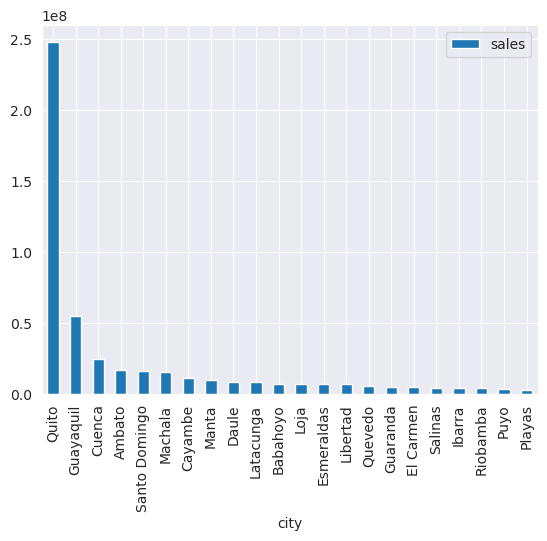

In [7]:
plot_1.plot.bar();

<br><br>

---

## Plot No. 2

In [8]:
# Plot no.2 - Sum of sales by 'type'
plot_2 = df_assignment.pivot_table(index='date', columns='type', values='sales', aggfunc='sum').astype('int')
plot_2

type,A,B,C,D,E
date,,,,,
2016-01-01,0,0,0,16433,0
2016-01-02,379618,161753,160188,311745,53370
2016-01-03,447037,191999,159407,356319,71971
2016-01-04,302539,130359,144323,324389,54345
2016-01-05,257060,126464,131458,261540,58796
...,...,...,...,...,...
2017-08-11,293910,111816,117835,243609,59201
2017-08-12,259813,108583,135502,229040,59690
2017-08-13,296839,130153,122696,241745,74205


<Axes: xlabel='date'>

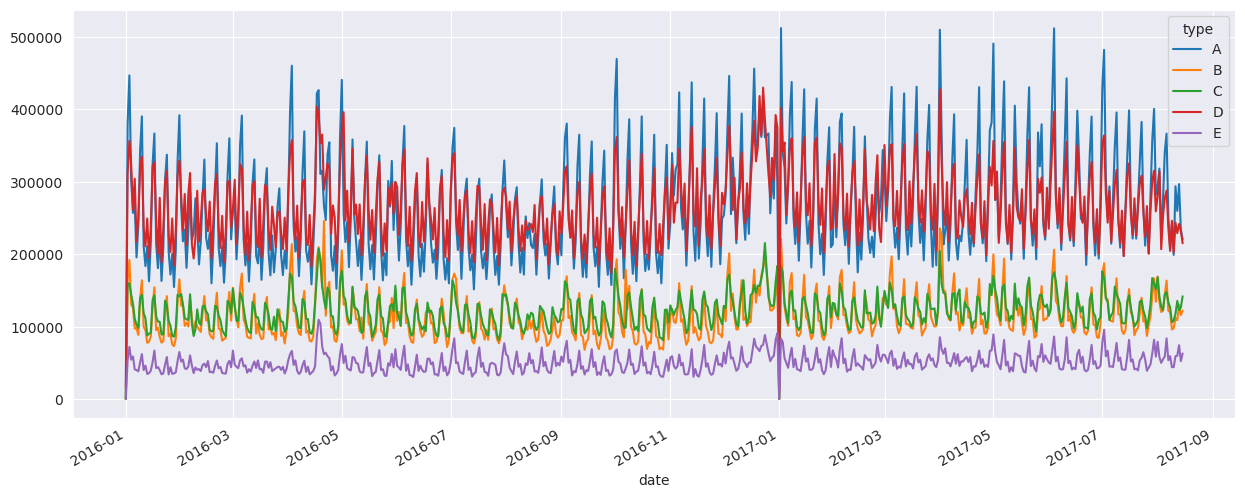

In [9]:
plot_2.plot(
    figsize=(15, 6)
)

<br><br>

---

## Plot No. 3

In [10]:
# Plot no.3 - Stacked bar chart with sales by month, with 'type' as the 'stacks'
plot_3 = (df_assignment
    .pivot_table(index=df_assignment.date.dt.month, 
                 columns='type', 
                 values='sales', 
                 aggfunc='mean')
    .round())

plot_3

type,A,B,C,D,E
date,,,,,
1,893.0,425.0,235.0,454.0,366.0
2,849.0,426.0,235.0,443.0,369.0
3,861.0,431.0,239.0,450.0,368.0
4,925.0,490.0,263.0,465.0,410.0
5,904.0,447.0,254.0,455.0,390.0
6,868.0,424.0,237.0,443.0,366.0
7,889.0,440.0,244.0,440.0,393.0
8,807.0,410.0,238.0,406.0,391.0
9,818.0,377.0,233.0,408.0,353.0


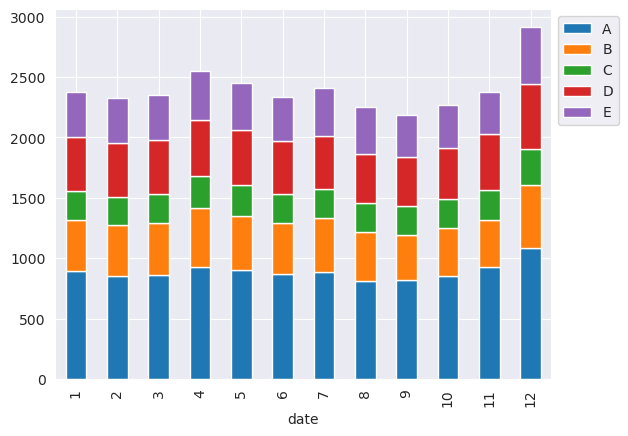

In [12]:
plot_3.plot.bar(stacked=True).legend(bbox_to_anchor=(1.15, 1));